# 第八章配套实验：GD 为什么会慢？zig-zag 与条件数

这个 Notebook 用二维病态二次函数展示梯度下降法为什么会慢，重点观察两件事：

1. 当水平集很狭长时，梯度下降轨迹会出现明显的 zig-zag；
2. 随着条件数 $\kappa$ 变大，达到同样精度所需的迭代次数会快速增加。

课堂使用建议：先运行公共函数，再依次运行实验 1、2、3。最常修改的参数是 `kappa`、`alpha_factor`、`x0`、`tol` 和 `max_iter`。

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PICS = BASE / "pics"
PICS.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 220
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "DejaVu Sans"]

SHANSHU = "#841e34"
BLUE = "#46445D"
DEEP_GREEN = "#0A6B3A"
ORANGE = "#AC7088"

print(f"图片会保存到: {PICS}")

图片会保存到: c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics


## 模型：一个可控条件数的二维二次函数

考虑

$$
f_\kappa(x)=\frac12(x_1^2+\kappa x_2^2),\qquad \kappa\ge 1.
$$

它的 Hessian 是

$$
Q=\begin{pmatrix}1&0\\0&\kappa\end{pmatrix},
$$

因此 $\mu=1$，$L=\kappa$，条件数就是

$$
\operatorname{cond}(Q)=\frac{L}{\mu}=\kappa.
$$

当 $\kappa$ 很大时，等高线是非常狭长的椭圆。梯度下降在陡峭方向容易来回越过谷底，在平坦方向又推进很慢，这就是课堂上常说的 zig-zag 现象。

In [4]:
def quad_f(x, kappa):
    """f_kappa(x)=1/2*(x1^2+kappa*x2^2)."""
    x = np.asarray(x, dtype=float)
    return 0.5 * (x[0]**2 + kappa * x[1]**2)


def quad_grad(x, kappa):
    """Gradient of f_kappa."""
    x = np.asarray(x, dtype=float)
    return np.array([x[0], kappa * x[1]], dtype=float)


def alpha_optimal(kappa):
    """Best constant step for a quadratic with eigenvalues 1 and kappa."""
    return 2.0 / (kappa + 1.0)


def spectral_radius(kappa, alpha):
    """Contraction factor of x_{k+1}=(I-alpha Q)x_k in Euclidean norm."""
    return max(abs(1.0 - alpha), abs(1.0 - alpha * kappa))


def gd_path(kappa=50, x0=(5.0, 4.0), alpha=None, max_iter=300, tol=1e-10):
    """Run fixed-step GD and return iterates, function values, relative errors."""
    if alpha is None:
        alpha = alpha_optimal(kappa)
    x = np.array(x0, dtype=float)
    xs = [x.copy()]
    fs = [quad_f(x, kappa)]
    f0 = max(fs[0], 1e-300)

    for _ in range(max_iter):
        x = x - alpha * quad_grad(x, kappa)
        xs.append(x.copy())
        fs.append(quad_f(x, kappa))
        if fs[-1] / f0 <= tol:
            break
        if (not np.all(np.isfinite(x))) or np.linalg.norm(x) > 1e12:
            break
    xs = np.array(xs)
    fs = np.array(fs)
    rel = fs / f0
    return xs, fs, rel, alpha


def plot_contours(ax, kappa, lim=5.5, levels=24):
    grid = np.linspace(-lim, lim, 400)
    X, Y = np.meshgrid(grid, grid)
    Z = 0.5 * (X**2 + kappa * Y**2)
    ax.contour(X, Y, Z, levels=levels, colors="0.70", linewidths=0.7)
    ax.set_aspect("equal", adjustable="box")
    ax.axhline(0, color="0.2", linewidth=0.5)
    ax.axvline(0, color="0.2", linewidth=0.5)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")


def plot_path(ax, xs, color=SHANSHU, label=None, max_arrows=18):
    ax.plot(xs[:, 0], xs[:, 1], "o-", color=color, markersize=2.8, linewidth=1.2, label=label)
    step = max(1, (len(xs) - 1) // max_arrows)
    for i in range(0, len(xs) - 1, step):
        ax.annotate(
            "",
            xy=xs[i + 1],
            xytext=xs[i],
            arrowprops=dict(arrowstyle="->", color=color, lw=1.0, shrinkA=0, shrinkB=0),
        )
    ax.scatter([0], [0], s=30, color=DEEP_GREEN, zorder=5, label=r"$x^\star$")


def iterations_to_tol(kappa, x0=(5.0, 4.0), tol=1e-6, max_iter=200000):
    xs, fs, rel, alpha = gd_path(kappa=kappa, x0=x0, alpha=alpha_optimal(kappa), max_iter=max_iter, tol=tol)
    empirical = len(rel) - 1 if rel[-1] <= tol else np.nan
    rho = spectral_radius(kappa, alpha)
    theoretical = int(np.ceil(np.log(tol) / (2 * np.log(rho)))) if rho < 1 else np.inf
    return empirical, theoretical, alpha, rho

## 实验 1：直接看 zig-zag 轨迹

这里使用理论上对二次函数较优的常数步长

$$
\alpha_\star=\frac{2}{L+\mu}=\frac{2}{\kappa+1}.
$$

对当前模型，两个特征方向上的迭代因子分别是

$$
1-\alpha_\star=\frac{\kappa-1}{\kappa+1},\qquad
1-\alpha_\star\kappa=-\frac{\kappa-1}{\kappa+1}.
$$

第二个方向的符号每一步翻转，因此轨迹会在谷底两侧来回摆动；而因子的绝对值接近 1 时，衰减又很慢。

alpha* = 0.039216, spectral radius = 0.960784, saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_gd_zigzag_kappa50.png


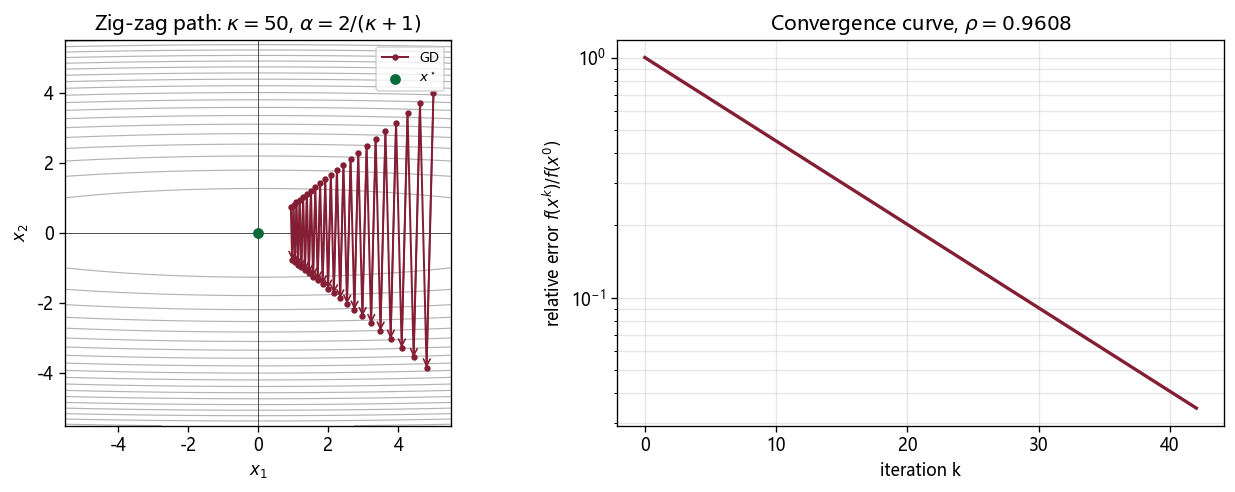

In [5]:
kappa = 50
x0 = (5.0, 4.0)
xs, fs, rel, alpha = gd_path(kappa=kappa, x0=x0, max_iter=42, tol=0.0)
rho = spectral_radius(kappa, alpha)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_contours(axes[0], kappa=kappa, lim=5.5)
plot_path(axes[0], xs, color=SHANSHU, label="GD")
axes[0].set_title(fr"Zig-zag path: $\kappa={kappa}$, $\alpha=2/(\kappa+1)$")
axes[0].legend(loc="upper right", fontsize=8)

axes[1].semilogy(rel, color=SHANSHU, linewidth=2)
axes[1].set_xlabel("iteration k")
axes[1].set_ylabel(r"relative error $f(x^k)/f(x^0)$")
axes[1].set_title(fr"Convergence curve, $\rho={rho:.4f}$")
axes[1].grid(True, which="both", alpha=0.3)

fig.tight_layout()
out = PICS / "chapter8_gd_zigzag_kappa50.png"
fig.savefig(out, bbox_inches="tight")
print(f"alpha* = {alpha:.6f}, spectral radius = {rho:.6f}, saved to {out}")

## 实验 2：条件数变大时，轨迹如何变化

下面把 $\kappa=2,10,50,200$ 放在同一张图中比较。需要注意：每个子图使用各自的 $\alpha_\star=2/(\kappa+1)$，所以这里比较的是“在较优常数步长下，条件数本身带来的困难”。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_gd_paths_by_kappa.png


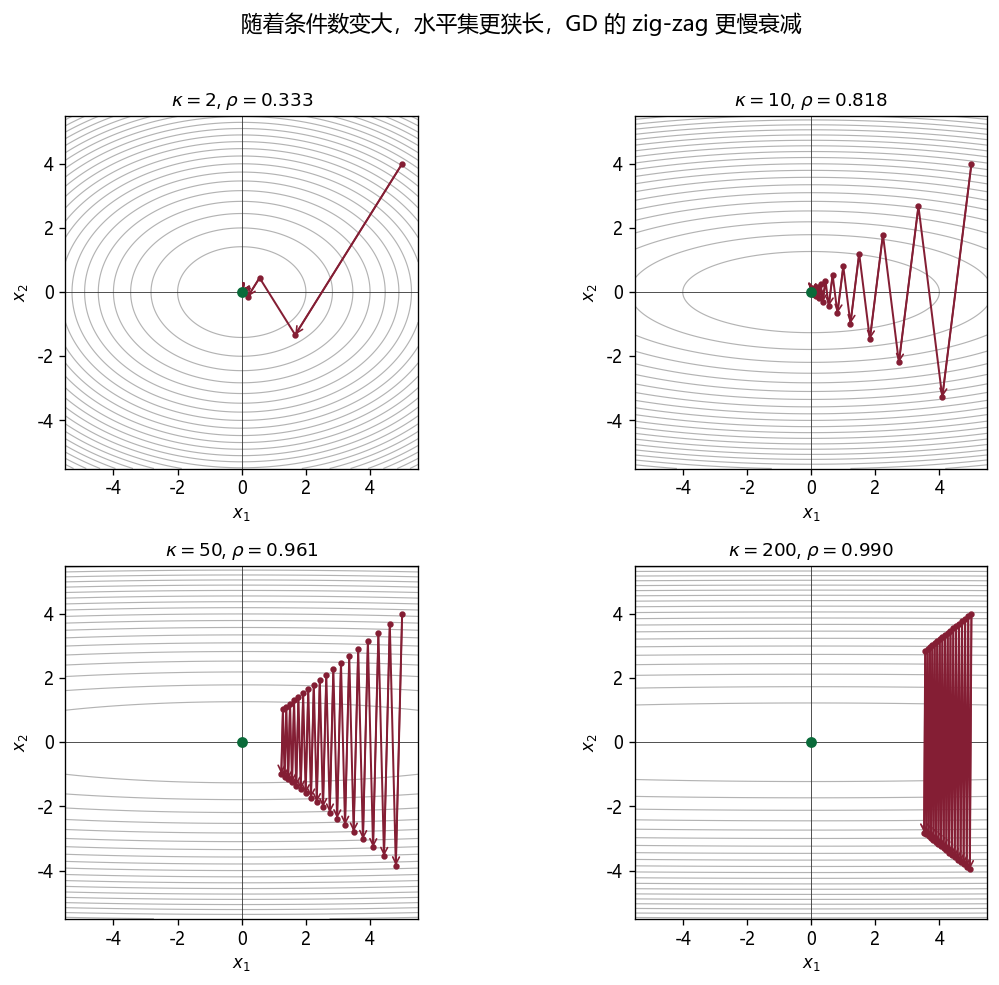

In [6]:
kappas = [2, 10, 50, 200]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, kappa in zip(axes, kappas):
    xs, fs, rel, alpha = gd_path(kappa=kappa, x0=x0, max_iter=35, tol=0.0)
    plot_contours(ax, kappa=kappa, lim=5.5)
    plot_path(ax, xs, color=SHANSHU, max_arrows=14)
    rho = spectral_radius(kappa, alpha)
    ax.set_title(fr"$\kappa={kappa}$, $\rho={rho:.3f}$", fontsize=11)

fig.suptitle("随着条件数变大，水平集更狭长，GD 的 zig-zag 更慢衰减", y=1.02, fontsize=13)
fig.tight_layout()
out = PICS / "chapter8_gd_paths_by_kappa.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 3：收敛速度如何随 $\kappa$ 变慢

对于这个二次模型，使用 $\alpha_\star=2/(\kappa+1)$ 时，迭代矩阵的谱半径为

$$
\rho_\star=\frac{\kappa-1}{\kappa+1}.
$$

当 $\kappa$ 增大时，$\rho_\star\to 1$，这意味着每一步的误差缩小比例越来越接近 1。因此，即使步长已经选得很好，GD 仍然会因为条件数大而变慢。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_gd_convergence_by_kappa.png


,kappa,alpha_star,rho_star,empirical_iters_to_1e-6,theoretical_rough_iters
0,2,0.666667,0.333333,7,7
1,5,0.333333,0.666667,18,18
2,10,0.181818,0.818182,35,35
3,20,0.095238,0.904762,70,70
4,50,0.039216,0.960784,173,173
5,100,0.019802,0.980198,346,346
6,200,0.009950,0.990050,691,691


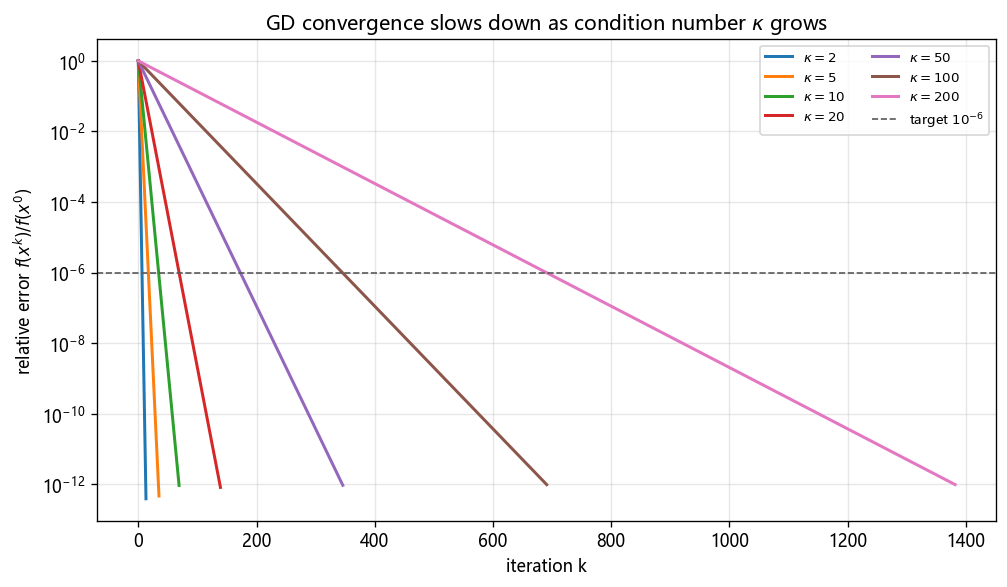

In [7]:
kappas = [2, 5, 10, 20, 50, 100, 200]
max_iter = 1500

fig, ax = plt.subplots(figsize=(8.5, 5))
summary_rows = []

for kappa in kappas:
    xs, fs, rel, alpha = gd_path(kappa=kappa, x0=x0, max_iter=max_iter, tol=1e-12)
    ax.semilogy(rel, linewidth=1.8, label=fr"$\kappa={kappa}$")
    empirical, theoretical, alpha, rho = iterations_to_tol(kappa, x0=x0, tol=1e-6)
    summary_rows.append({
        "kappa": kappa,
        "alpha_star": alpha,
        "rho_star": rho,
        "empirical_iters_to_1e-6": empirical,
        "theoretical_rough_iters": theoretical,
    })

ax.axhline(1e-6, color="0.35", linestyle="--", linewidth=1.0, label="target $10^{-6}$")
ax.set_xlabel("iteration k")
ax.set_ylabel(r"relative error $f(x^k)/f(x^0)$")
ax.set_title(r"GD convergence slows down as condition number $\kappa$ grows")
ax.grid(True, which="both", alpha=0.3)
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
out = PICS / "chapter8_gd_convergence_by_kappa.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

summary = pd.DataFrame(summary_rows)
summary

## 实验 4：迭代次数与条件数的关系

上一张图说明了曲线变慢。下面直接画“达到相同精度所需迭代次数”与 $\kappa$ 的关系。对于强凸二次函数，GD 的复杂度量级与 $\kappa \log(1/\varepsilon)$ 一致，因此这里应该看到近似线性的增长趋势。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_gd_iters_vs_kappa.png


,kappa,empirical_iters,theoretical_rough_iters,alpha_star,rho_star
0,2,7,7,0.666667,0.333333
1,3,10,10,0.500000,0.500000
2,5,18,18,0.333333,0.666667
3,8,28,28,0.222222,0.777778
4,10,35,35,0.181818,0.818182
5,15,52,52,0.125000,0.875000
6,20,70,70,0.095238,0.904762
7,30,104,104,0.064516,0.935484
8,50,173,173,0.039216,0.960784
9,80,277,277,0.024691,0.975309


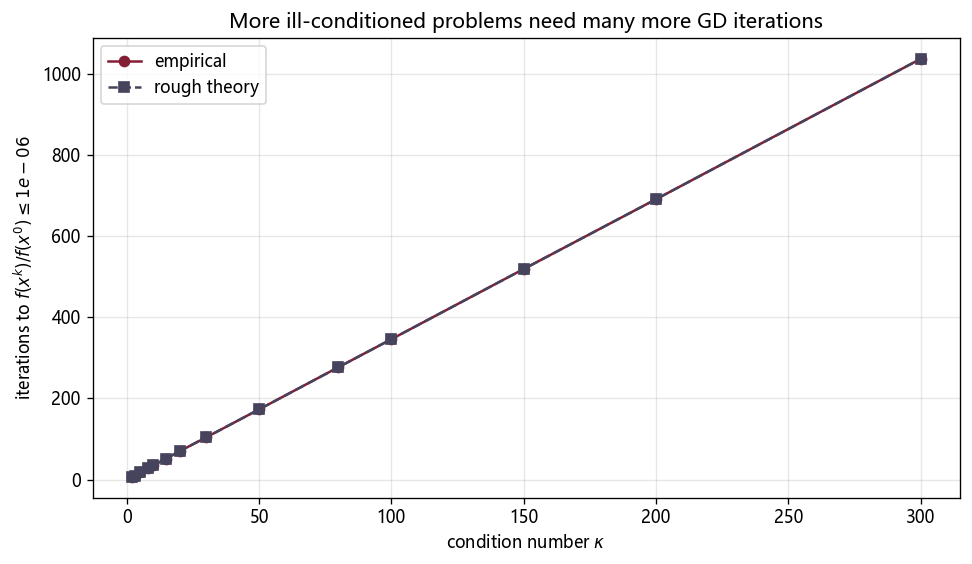

In [8]:
kappa_grid = np.array([2, 3, 5, 8, 10, 15, 20, 30, 50, 80, 100, 150, 200, 300])
tol = 1e-6
rows = []
for kappa in kappa_grid:
    empirical, theoretical, alpha, rho = iterations_to_tol(kappa, x0=x0, tol=tol)
    rows.append((kappa, empirical, theoretical, alpha, rho))

iters_df = pd.DataFrame(rows, columns=["kappa", "empirical_iters", "theoretical_rough_iters", "alpha_star", "rho_star"])

fig, ax = plt.subplots(figsize=(8.2, 4.8))
ax.plot(iters_df["kappa"], iters_df["empirical_iters"], "o-", color=SHANSHU, label="empirical")
ax.plot(iters_df["kappa"], iters_df["theoretical_rough_iters"], "s--", color=BLUE, label="rough theory")
ax.set_xlabel(r"condition number $\kappa$")
ax.set_ylabel(fr"iterations to $f(x^k)/f(x^0)\leq {tol:g}$")
ax.set_title("More ill-conditioned problems need many more GD iterations")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
out = PICS / "chapter8_gd_iters_vs_kappa.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

iters_df

## 可修改课堂演示单元

如果想在课堂上快速演示，可以只改下面几个参数：

- `kappa_demo`：条件数，越大越病态；
- `alpha_factor`：相对于 $\alpha_\star=2/(\kappa+1)$ 的倍数；
- `x0_demo`：初始点；
- `max_iter_demo`：最多显示多少步。

建议尝试：

1. 固定 `alpha_factor=1.0`，把 `kappa_demo` 从 5 改到 50、200；
2. 固定 `kappa_demo=50`，把 `alpha_factor` 改成 0.5、1.0、1.05，观察收敛、震荡和不稳定的变化。

alpha_star=0.0645161, alpha_used=0.0645161, rho=0.935484


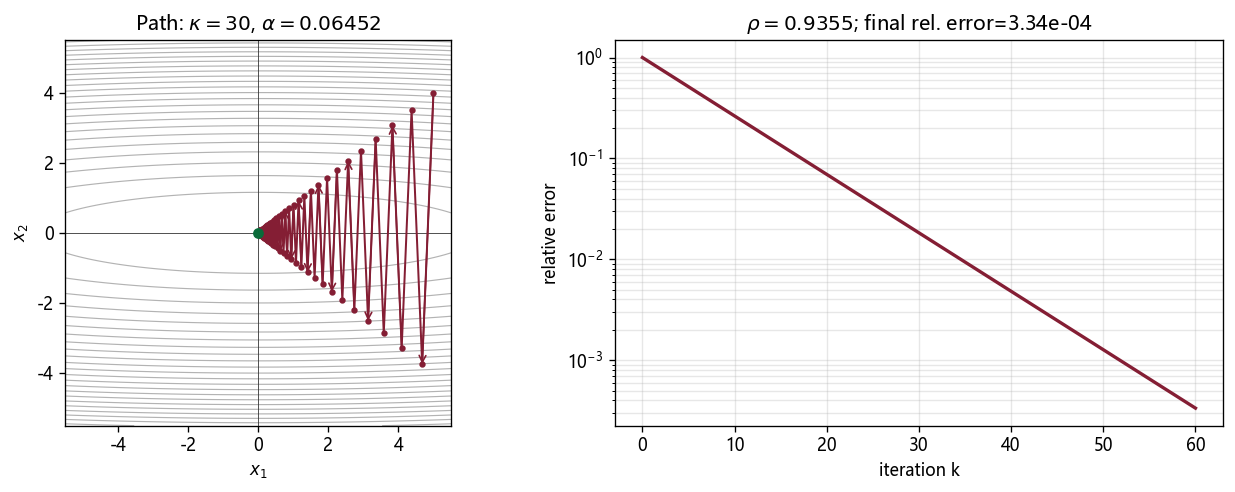

In [9]:
kappa_demo = 30
alpha_factor = 1.0
x0_demo = (5.0, 4.0)
max_iter_demo = 60

alpha_demo = alpha_factor * alpha_optimal(kappa_demo)
xs, fs, rel, _ = gd_path(kappa=kappa_demo, x0=x0_demo, alpha=alpha_demo, max_iter=max_iter_demo, tol=0.0)
rho_demo = spectral_radius(kappa_demo, alpha_demo)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
plot_contours(axes[0], kappa=kappa_demo, lim=5.5)
plot_path(axes[0], xs, color=SHANSHU, max_arrows=20)
axes[0].set_title(fr"Path: $\kappa={kappa_demo}$, $\alpha={alpha_demo:.4g}$")

axes[1].semilogy(rel, color=SHANSHU, linewidth=2)
axes[1].set_xlabel("iteration k")
axes[1].set_ylabel(r"relative error")
axes[1].set_title(fr"$\rho={rho_demo:.4f}$; final rel. error={rel[-1]:.2e}")
axes[1].grid(True, which="both", alpha=0.3)

fig.tight_layout()
print(f"alpha_star={alpha_optimal(kappa_demo):.6g}, alpha_used={alpha_demo:.6g}, rho={rho_demo:.6g}")

## 课堂结论

这个实验对应课件中的“GD 为什么会慢”。可以用三句话总结：

1. 条件数 $\kappa$ 越大，水平集越狭长；
2. 梯度方向与通向最优点的方向可能差别很大，因此轨迹会 zig-zag；
3. 即使使用较优常数步长，收敛因子 $\rho_\star=(\kappa-1)/(\kappa+1)$ 也会随着 $\kappa$ 增大而趋近于 1，所以 GD 需要更多迭代。

这正是引入动量法、Nesterov 加速、牛顿法和拟牛顿法的动机：它们都试图更有效地利用方向、历史或曲率信息。

## 补充实验 5：加入 Heavy-ball 动量法

前面的实验展示了普通 GD 在病态二次函数上的 zig-zag。现在加入 Heavy-ball 动量法：

$$
x^{k+1}=x^k-\alpha\nabla f(x^k)+\beta(x^k-x^{k-1}).
$$

对二次函数且特征值位于 $[\mu,L]$ 的理想情形，常用的理论参数为

$$
\alpha_{HB}=\frac{4}{(\sqrt L+\sqrt\mu)^2},\qquad
\beta_{HB}=\left(\frac{\sqrt L-\sqrt\mu}{\sqrt L+\sqrt\mu}\right)^2.
$$

在当前模型中 $\mu=1$、$L=\kappa$，因此

$$
\alpha_{HB}=\frac{4}{(\sqrt\kappa+1)^2},\qquad
\beta_{HB}=\left(\frac{\sqrt\kappa-1}{\sqrt\kappa+1}\right)^2.
$$

这个实验主要比较两件事：动量法的轨迹是否减少 zig-zag，以及函数值下降是否更快。

In [10]:
def heavy_ball_params(kappa):
    """The classical optimal Heavy-ball parameters for eigenvalues in [1, kappa]."""
    sqrt_kappa = np.sqrt(kappa)
    alpha = 4.0 / (sqrt_kappa + 1.0) ** 2
    beta = ((sqrt_kappa - 1.0) / (sqrt_kappa + 1.0)) ** 2
    rho = (sqrt_kappa - 1.0) / (sqrt_kappa + 1.0)
    return alpha, beta, rho


def heavy_ball_path(kappa=50, x0=(5.0, 4.0), alpha=None, beta=None, max_iter=300, tol=1e-10):
    """Run Heavy-ball momentum on f_kappa with zero initial velocity."""
    if alpha is None or beta is None:
        alpha_auto, beta_auto, _ = heavy_ball_params(kappa)
        alpha = alpha_auto if alpha is None else alpha
        beta = beta_auto if beta is None else beta

    x = np.array(x0, dtype=float)
    v = np.zeros_like(x)
    xs = [x.copy()]
    fs = [quad_f(x, kappa)]
    f0 = max(fs[0], 1e-300)

    for _ in range(max_iter):
        v = beta * v - alpha * quad_grad(x, kappa)
        x = x + v
        xs.append(x.copy())
        fs.append(quad_f(x, kappa))
        if fs[-1] / f0 <= tol:
            break
        if (not np.all(np.isfinite(x))) or np.linalg.norm(x) > 1e12:
            break
    xs = np.array(xs)
    fs = np.array(fs)
    rel = fs / f0
    return xs, fs, rel, alpha, beta


def momentum_iterations_to_tol(kappa, x0=(5.0, 4.0), tol=1e-6, max_iter=200000):
    xs, fs, rel, alpha, beta = heavy_ball_path(kappa=kappa, x0=x0, max_iter=max_iter, tol=tol)
    empirical = len(rel) - 1 if rel[-1] <= tol else np.nan
    _, _, rho = heavy_ball_params(kappa)
    rough_theory = int(np.ceil(np.log(tol) / (2 * np.log(rho)))) if rho < 1 else np.inf
    return empirical, rough_theory, alpha, beta, rho

## 实验 6：GD 与 Heavy-ball 的轨迹对比

下面固定 $\kappa=50$。GD 使用较优常数步长 $2/(\kappa+1)$，Heavy-ball 使用上面的理论参数。注意动量法的轨迹不一定每一步都单调下降，但它通常能更快穿过狭长谷底。

GD alpha=0.039216
Heavy-ball alpha=0.061404, beta=0.565807, rho≈0.752201
saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_gd_vs_heavy_ball_kappa50.png


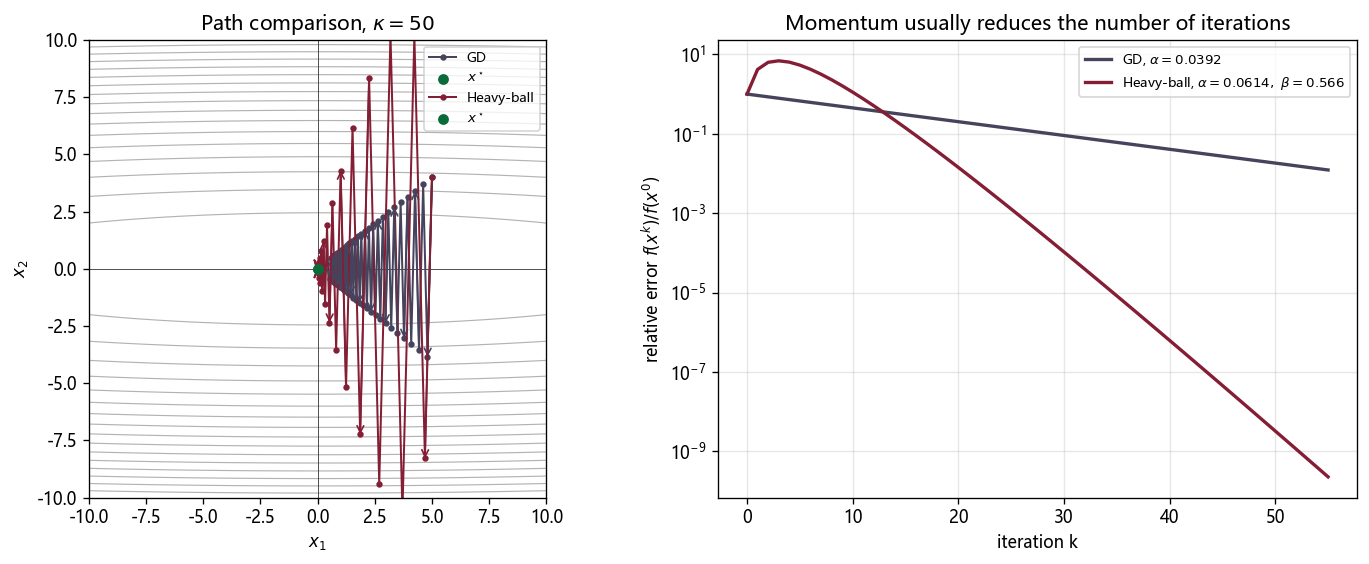

In [11]:
kappa = 50
x0 = (5.0, 4.0)
max_iter_show = 55

gd_xs, gd_fs, gd_rel, gd_alpha = gd_path(kappa=kappa, x0=x0, max_iter=max_iter_show, tol=0.0)
hb_xs, hb_fs, hb_rel, hb_alpha, hb_beta = heavy_ball_path(kappa=kappa, x0=x0, max_iter=max_iter_show, tol=0.0)
_, _, hb_rho = heavy_ball_params(kappa)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
plot_contours(axes[0], kappa=kappa, lim=10.0)
plot_path(axes[0], gd_xs, color=BLUE, label="GD", max_arrows=16)
plot_path(axes[0], hb_xs, color=SHANSHU, label="Heavy-ball", max_arrows=16)
axes[0].set_title(fr"Path comparison, $\kappa={kappa}$")
axes[0].legend(fontsize=8)

axes[1].semilogy(gd_rel, color=BLUE, linewidth=2, label=fr"GD, $\alpha={gd_alpha:.4f}$")
axes[1].semilogy(hb_rel, color=SHANSHU, linewidth=2, label=fr"Heavy-ball, $\alpha={hb_alpha:.4f},\ \beta={hb_beta:.3f}$")
axes[1].set_xlabel("iteration k")
axes[1].set_ylabel(r"relative error $f(x^k)/f(x^0)$")
axes[1].set_title("Momentum usually reduces the number of iterations")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8)

fig.tight_layout()
out = PICS / "chapter8_gd_vs_heavy_ball_kappa50.png"
fig.savefig(out, bbox_inches="tight")
print(f"GD alpha={gd_alpha:.6f}")
print(f"Heavy-ball alpha={hb_alpha:.6f}, beta={hb_beta:.6f}, rho≈{hb_rho:.6f}")
print(f"saved to {out}")

## 实验 7：不同条件数下的提升效果

这里比较 GD 与 Heavy-ball 在不同 $\kappa$ 下的函数值下降曲线。为了突出趋势，每个 $\kappa$ 都使用各自的理论推荐参数。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_heavy_ball_speedup_by_kappa.png


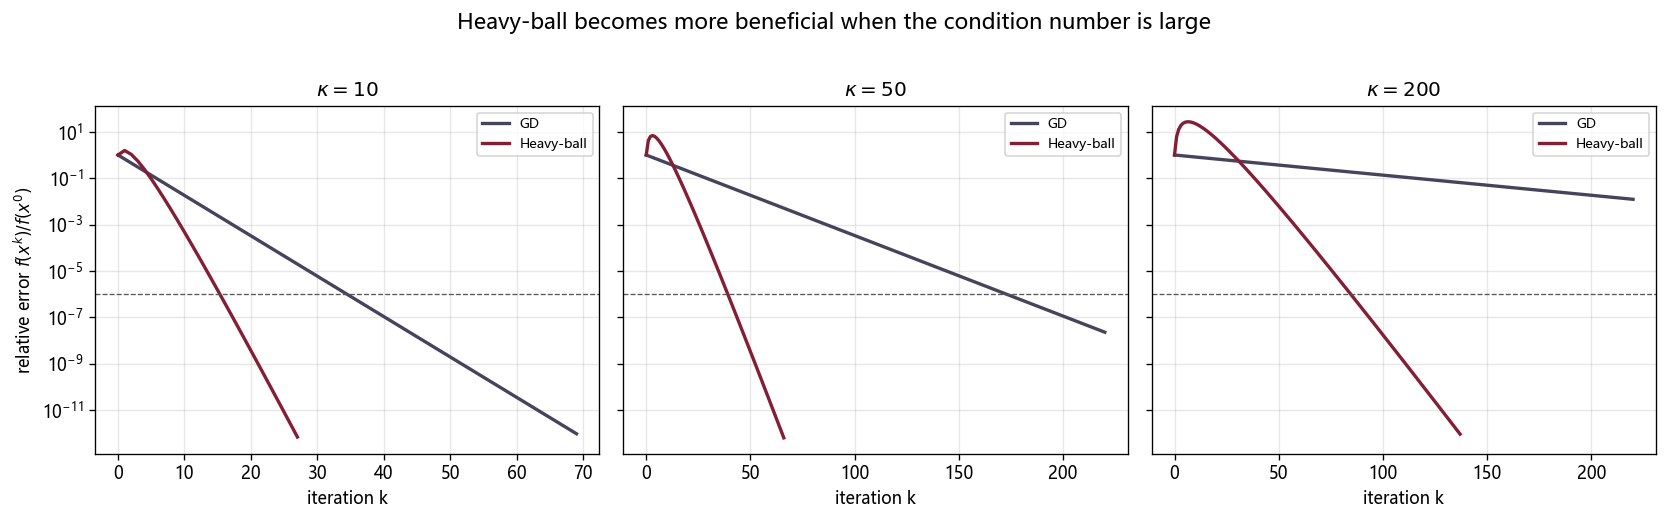

In [12]:
kappas = [10, 50, 200]
max_iter = 220
fig, axes = plt.subplots(1, len(kappas), figsize=(14, 4.2), sharey=True)

for ax, kappa in zip(axes, kappas):
    gd_xs, gd_fs, gd_rel, gd_alpha = gd_path(kappa=kappa, x0=x0, max_iter=max_iter, tol=1e-12)
    hb_xs, hb_fs, hb_rel, hb_alpha, hb_beta = heavy_ball_path(kappa=kappa, x0=x0, max_iter=max_iter, tol=1e-12)
    ax.semilogy(gd_rel, color=BLUE, linewidth=2, label="GD")
    ax.semilogy(hb_rel, color=SHANSHU, linewidth=2, label="Heavy-ball")
    ax.axhline(1e-6, color="0.35", linestyle="--", linewidth=0.8)
    ax.set_title(fr"$\kappa={kappa}$")
    ax.set_xlabel("iteration k")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"relative error $f(x^k)/f(x^0)$")
fig.suptitle("Heavy-ball becomes more beneficial when the condition number is large", y=1.02, fontsize=13)
fig.tight_layout()
out = PICS / "chapter8_heavy_ball_speedup_by_kappa.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 8：达到同样精度需要多少步？

普通 GD 的典型条件数依赖是 $\mathcal O(\kappa\log(1/\varepsilon))$；Heavy-ball 在理想强凸二次情形下的收敛因子与

$$
\frac{\sqrt\kappa-1}{\sqrt\kappa+1}
$$

相关，因此迭代次数的增长更接近 $\sqrt\kappa$ 量级。下面用数值实验直接比较。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_heavy_ball_iteration_speedup.png


,kappa,GD_iters,HB_iters,speedup_GD_over_HB,GD_rho,HB_rho,HB_beta
0,2,7,5,1.400000,0.333333,0.171573,0.029437
1,3,10,7,1.428571,0.500000,0.267949,0.071797
2,5,18,10,1.800000,0.666667,0.381966,0.145898
3,8,28,14,2.000000,0.777778,0.477592,0.228094
4,10,35,16,2.187500,0.818182,0.519494,0.269874
5,15,52,20,2.600000,0.875000,0.589574,0.347597
6,20,70,24,2.916667,0.904762,0.634512,0.402605
7,30,104,30,3.466667,0.935484,0.691226,0.477793
8,50,173,40,4.325000,0.960784,0.752201,0.565807
9,80,277,51,5.431373,0.975309,0.798879,0.638208


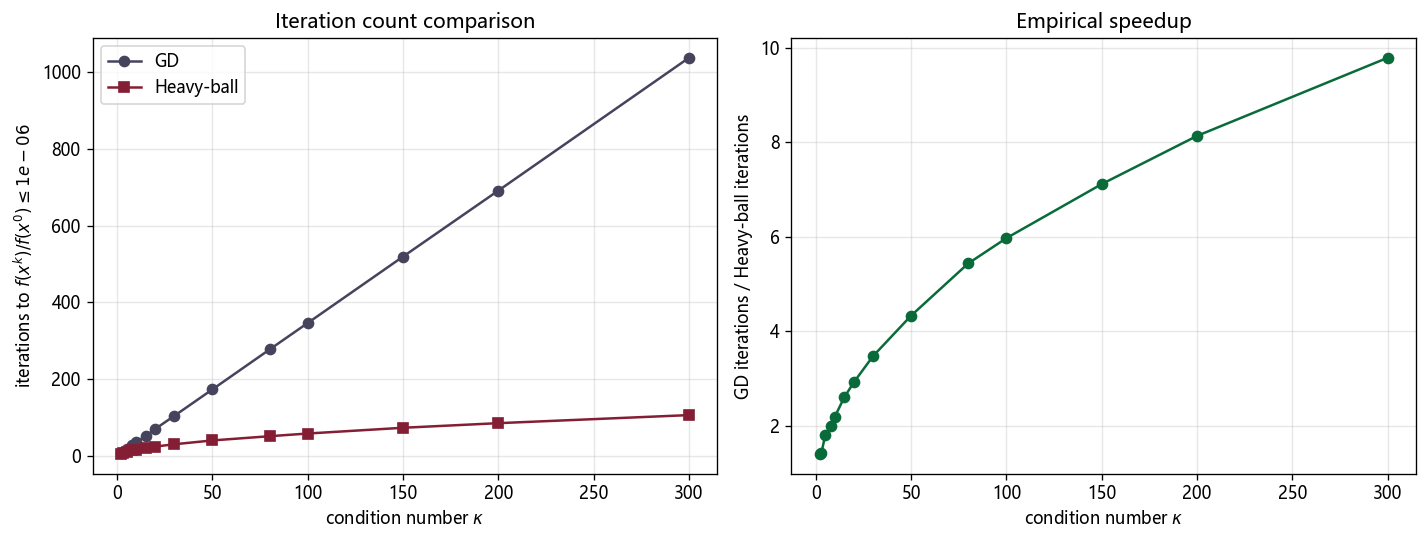

In [13]:
kappa_grid = np.array([2, 3, 5, 8, 10, 15, 20, 30, 50, 80, 100, 150, 200, 300])
tol = 1e-6
rows = []

for kappa in kappa_grid:
    gd_emp, gd_theory, gd_alpha, gd_rho = iterations_to_tol(kappa, x0=x0, tol=tol)
    hb_emp, hb_theory, hb_alpha, hb_beta, hb_rho = momentum_iterations_to_tol(kappa, x0=x0, tol=tol)
    rows.append({
        "kappa": kappa,
        "GD_iters": gd_emp,
        "HB_iters": hb_emp,
        "speedup_GD_over_HB": gd_emp / hb_emp,
        "GD_rho": gd_rho,
        "HB_rho": hb_rho,
        "HB_beta": hb_beta,
    })

speed_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(speed_df["kappa"], speed_df["GD_iters"], "o-", color=BLUE, label="GD")
axes[0].plot(speed_df["kappa"], speed_df["HB_iters"], "s-", color=SHANSHU, label="Heavy-ball")
axes[0].set_xlabel(r"condition number $\kappa$")
axes[0].set_ylabel(fr"iterations to $f(x^k)/f(x^0)\leq {tol:g}$")
axes[0].set_title("Iteration count comparison")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(speed_df["kappa"], speed_df["speedup_GD_over_HB"], "o-", color=DEEP_GREEN)
axes[1].set_xlabel(r"condition number $\kappa$")
axes[1].set_ylabel("GD iterations / Heavy-ball iterations")
axes[1].set_title("Empirical speedup")
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
out = PICS / "chapter8_heavy_ball_iteration_speedup.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

speed_df

## 动量法实验结论

从这些图可以强调三个课堂结论：

1. Heavy-ball 仍然可能有振荡，因为它带有惯性；但这种振荡通常更有方向性，不再像 GD 那样只是在狭长谷底两侧缓慢 zig-zag。
2. 在病态二次函数上，动量法可以显著减少达到同样精度所需的迭代次数。
3. 条件数越大，GD 的劣势越明显，动量法的提升也越容易被观察到。

这为下一步讲 Nesterov 加速提供了自然过渡：Heavy-ball 说明“历史方向”确实有价值，而 Nesterov 方法进一步把梯度计算放到前瞻点，从而获得更清晰的理论保证。

## 补充实验 9：Nesterov 加速梯度法（NAG）

Heavy-ball 方法说明了“历史方向”可以帮助算法加速。Nesterov 加速梯度法进一步改变梯度的计算位置：不是在当前点 $x^k$ 计算梯度，而是在前瞻点

$$
y^k=x^k+\beta(x^k-x^{k-1})
$$

计算梯度，然后更新

$$
x^{k+1}=y^k-\alpha\nabla f(y^k).
$$

对 $\mu$-强凸、$L$-光滑问题，一个常见参数选择是

$$
\alpha_{NAG}=\frac1L,\qquad
\beta_{NAG}=\frac{\sqrt L-\sqrt\mu}{\sqrt L+\sqrt\mu}.
$$

在当前模型中 $\mu=1$、$L=\kappa$，所以

$$
\alpha_{NAG}=\frac1\kappa,
\qquad
\beta_{NAG}=\frac{\sqrt\kappa-1}{\sqrt\kappa+1}.
$$

下面沿用同一个病态二次函数，比较 GD、Heavy-ball 和 NAG 的轨迹与收敛速度。

In [14]:
def nag_params(kappa):
    """Strongly-convex NAG parameters for eigenvalues in [1, kappa]."""
    sqrt_kappa = np.sqrt(kappa)
    alpha = 1.0 / kappa
    beta = (sqrt_kappa - 1.0) / (sqrt_kappa + 1.0)
    rho = 1.0 - 1.0 / sqrt_kappa
    return alpha, beta, rho


def nag_path(kappa=50, x0=(5.0, 4.0), alpha=None, beta=None, max_iter=300, tol=1e-10):
    """Run Nesterov accelerated gradient on f_kappa."""
    if alpha is None or beta is None:
        alpha_auto, beta_auto, _ = nag_params(kappa)
        alpha = alpha_auto if alpha is None else alpha
        beta = beta_auto if beta is None else beta

    x_prev = np.array(x0, dtype=float)
    x = x_prev.copy()
    xs = [x.copy()]
    fs = [quad_f(x, kappa)]
    f0 = max(fs[0], 1e-300)

    for _ in range(max_iter):
        y = x + beta * (x - x_prev)
        x_next = y - alpha * quad_grad(y, kappa)
        x_prev, x = x, x_next
        xs.append(x.copy())
        fs.append(quad_f(x, kappa))
        if fs[-1] / f0 <= tol:
            break
        if (not np.all(np.isfinite(x))) or np.linalg.norm(x) > 1e12:
            break
    xs = np.array(xs)
    fs = np.array(fs)
    rel = fs / f0
    return xs, fs, rel, alpha, beta


def nag_iterations_to_tol(kappa, x0=(5.0, 4.0), tol=1e-6, max_iter=200000):
    xs, fs, rel, alpha, beta = nag_path(kappa=kappa, x0=x0, max_iter=max_iter, tol=tol)
    empirical = len(rel) - 1 if rel[-1] <= tol else np.nan
    _, _, rho = nag_params(kappa)
    rough_theory = int(np.ceil(np.log(tol) / (2 * np.log(rho)))) if 0 < rho < 1 else np.inf
    return empirical, rough_theory, alpha, beta, rho

## 实验 10：GD、Heavy-ball 与 NAG 的轨迹对比

下面仍然固定 $\kappa=50$。三种方法的参数分别为：

- GD：使用较优常数步长 $2/(\kappa+1)$；
- Heavy-ball：使用二次函数上的理论推荐参数；
- NAG：使用强凸光滑情形下的常见参数 $\alpha=1/L$ 与 $\beta=(\sqrt\kappa-1)/(\sqrt\kappa+1)$。

观察重点不是某一步是否单调下降，而是整体轨迹是否更快进入最优点附近。

GD alpha=0.039216
Heavy-ball alpha=0.061404, beta=0.565807
NAG alpha=0.020000, beta=0.752201
saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_gd_hb_nag_path_kappa50.png


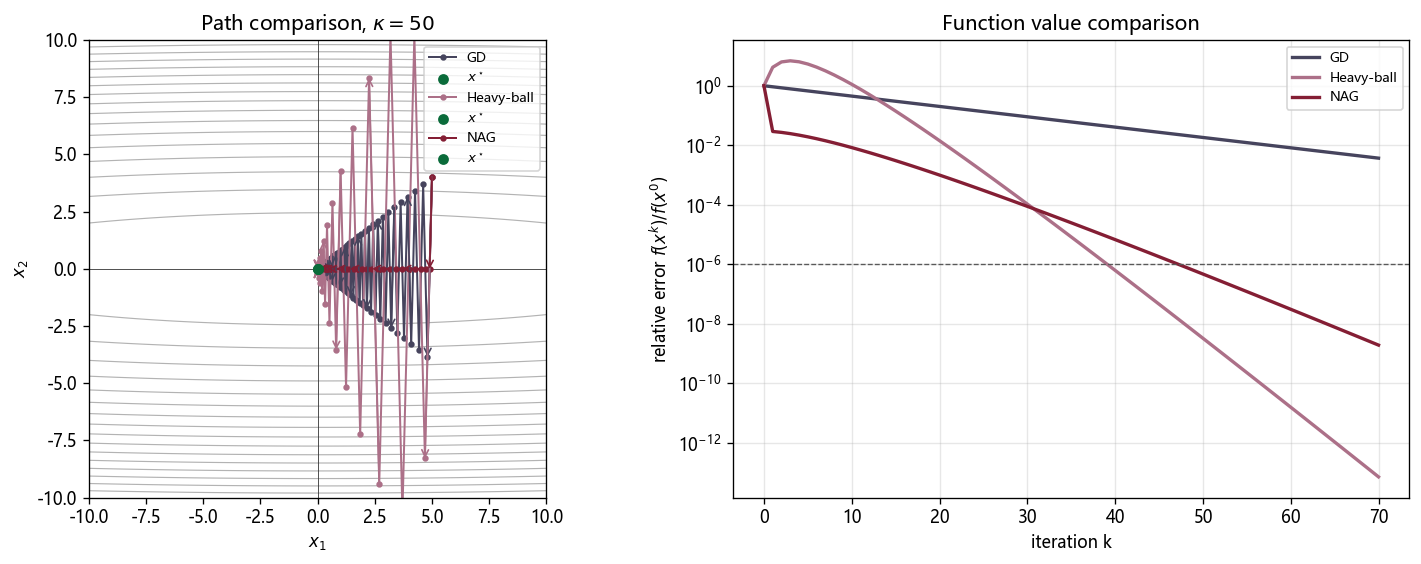

In [15]:
kappa = 50
x0 = (5.0, 4.0)
max_iter_show = 70

gd_xs, gd_fs, gd_rel, gd_alpha = gd_path(kappa=kappa, x0=x0, max_iter=max_iter_show, tol=0.0)
hb_xs, hb_fs, hb_rel, hb_alpha, hb_beta = heavy_ball_path(kappa=kappa, x0=x0, max_iter=max_iter_show, tol=0.0)
nag_xs, nag_fs, nag_rel, nag_alpha, nag_beta = nag_path(kappa=kappa, x0=x0, max_iter=max_iter_show, tol=0.0)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
plot_contours(axes[0], kappa=kappa, lim=10.0)
plot_path(axes[0], gd_xs, color=BLUE, label="GD", max_arrows=14)
plot_path(axes[0], hb_xs, color=ORANGE, label="Heavy-ball", max_arrows=14)
plot_path(axes[0], nag_xs, color=SHANSHU, label="NAG", max_arrows=14)
axes[0].set_title(fr"Path comparison, $\kappa={kappa}$")
axes[0].legend(fontsize=8)

axes[1].semilogy(gd_rel, color=BLUE, linewidth=2, label=fr"GD")
axes[1].semilogy(hb_rel, color=ORANGE, linewidth=2, label="Heavy-ball")
axes[1].semilogy(nag_rel, color=SHANSHU, linewidth=2, label="NAG")
axes[1].axhline(1e-6, color="0.35", linestyle="--", linewidth=0.8)
axes[1].set_xlabel("iteration k")
axes[1].set_ylabel(r"relative error $f(x^k)/f(x^0)$")
axes[1].set_title("Function value comparison")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8)

fig.tight_layout()
out = PICS / "chapter8_gd_hb_nag_path_kappa50.png"
fig.savefig(out, bbox_inches="tight")
print(f"GD alpha={gd_alpha:.6f}")
print(f"Heavy-ball alpha={hb_alpha:.6f}, beta={hb_beta:.6f}")
print(f"NAG alpha={nag_alpha:.6f}, beta={nag_beta:.6f}")
print(f"saved to {out}")

## 实验 11：不同条件数下 NAG 的提升效果

下面比较 $\kappa=10,50,200$ 三种病态程度下的函数值曲线。NAG 相比 GD 的优势会随着 $\kappa$ 增大而更明显；Heavy-ball 在这个理想二次函数上通常也很强，但 NAG 的理论保证更适合一般光滑凸优化课程主线。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_nag_speedup_by_kappa.png


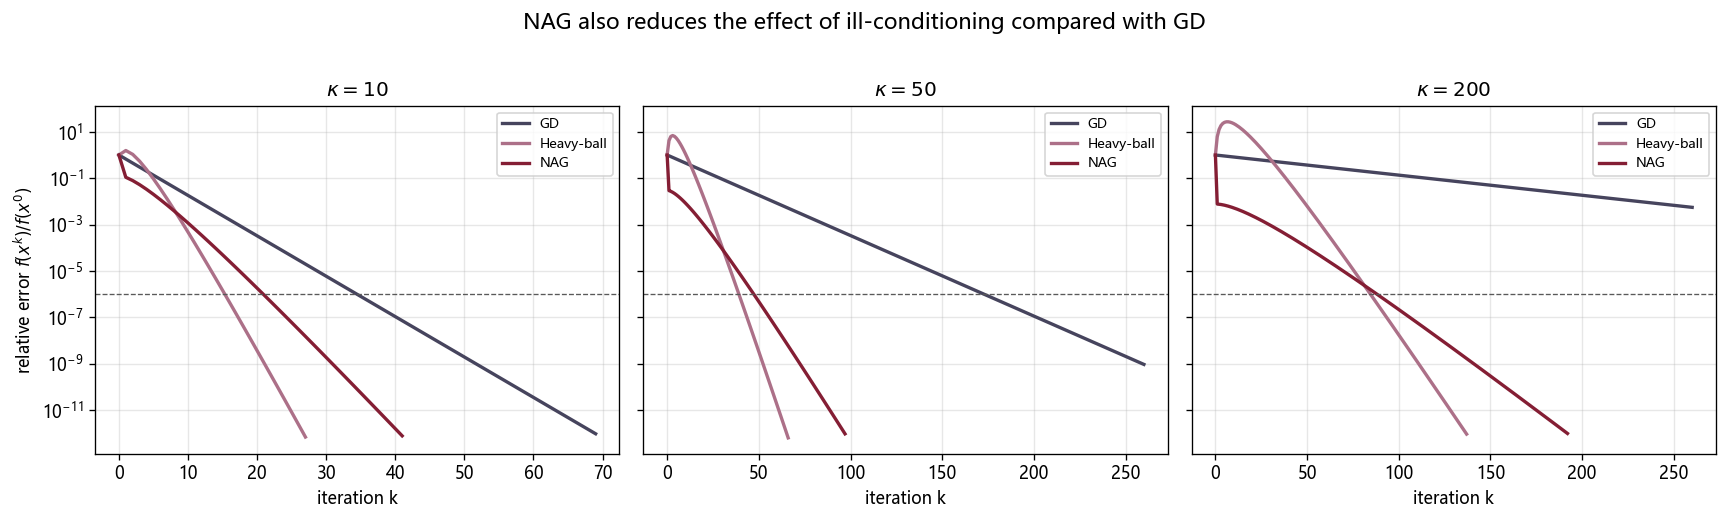

In [16]:
kappas = [10, 50, 200]
max_iter = 260
fig, axes = plt.subplots(1, len(kappas), figsize=(14.5, 4.2), sharey=True)

for ax, kappa in zip(axes, kappas):
    gd_xs, gd_fs, gd_rel, gd_alpha = gd_path(kappa=kappa, x0=x0, max_iter=max_iter, tol=1e-12)
    hb_xs, hb_fs, hb_rel, hb_alpha, hb_beta = heavy_ball_path(kappa=kappa, x0=x0, max_iter=max_iter, tol=1e-12)
    nag_xs, nag_fs, nag_rel, nag_alpha, nag_beta = nag_path(kappa=kappa, x0=x0, max_iter=max_iter, tol=1e-12)
    ax.semilogy(gd_rel, color=BLUE, linewidth=2, label="GD")
    ax.semilogy(hb_rel, color=ORANGE, linewidth=2, label="Heavy-ball")
    ax.semilogy(nag_rel, color=SHANSHU, linewidth=2, label="NAG")
    ax.axhline(1e-6, color="0.35", linestyle="--", linewidth=0.8)
    ax.set_title(fr"$\kappa={kappa}$")
    ax.set_xlabel("iteration k")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel(r"relative error $f(x^k)/f(x^0)$")
fig.suptitle("NAG also reduces the effect of ill-conditioning compared with GD", y=1.02, fontsize=13)
fig.tight_layout()
out = PICS / "chapter8_nag_speedup_by_kappa.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

## 实验 12：迭代次数对比：GD vs Heavy-ball vs NAG

这一页用表格和曲线比较三种方法达到相同精度所需的迭代次数。

需要提醒学生：这里的 Heavy-ball 参数是针对二次函数的经典最优参数，因此在这个特定例子上可能非常强；NAG 的重要性在于它在一般光滑凸/强凸问题上有更系统的理论保证。

<>:36: SyntaxWarning: invalid escape sequence '\k'
<>:36: SyntaxWarning: invalid escape sequence '\k'
C:\Users\zhenw\AppData\Local\Temp\ipykernel_35784\2848969902.py:36: SyntaxWarning: invalid escape sequence '\k'
  axes[1].set_title("Acceleration becomes clearer as $\kappa$ grows")


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_gd_hb_nag_iteration_speedup.png


,kappa,GD_iters,HB_iters,NAG_iters,GD_over_NAG,GD_over_HB,NAG_beta,NAG_rho_rough
0,2,7,5,7,1.000000,1.400000,0.171573,0.292893
1,3,10,7,10,1.000000,1.428571,0.267949,0.422650
2,5,18,10,14,1.285714,1.800000,0.381966,0.552786
3,8,28,14,19,1.473684,2.000000,0.477592,0.646447
4,10,35,16,21,1.666667,2.187500,0.519494,0.683772
5,15,52,20,27,1.925926,2.600000,0.589574,0.741801
6,20,70,24,31,2.258065,2.916667,0.634512,0.776393
7,30,104,30,37,2.810811,3.466667,0.691226,0.817426
8,50,173,40,48,3.604167,4.325000,0.752201,0.858579
9,80,277,51,59,4.694915,5.431373,0.798879,0.888197


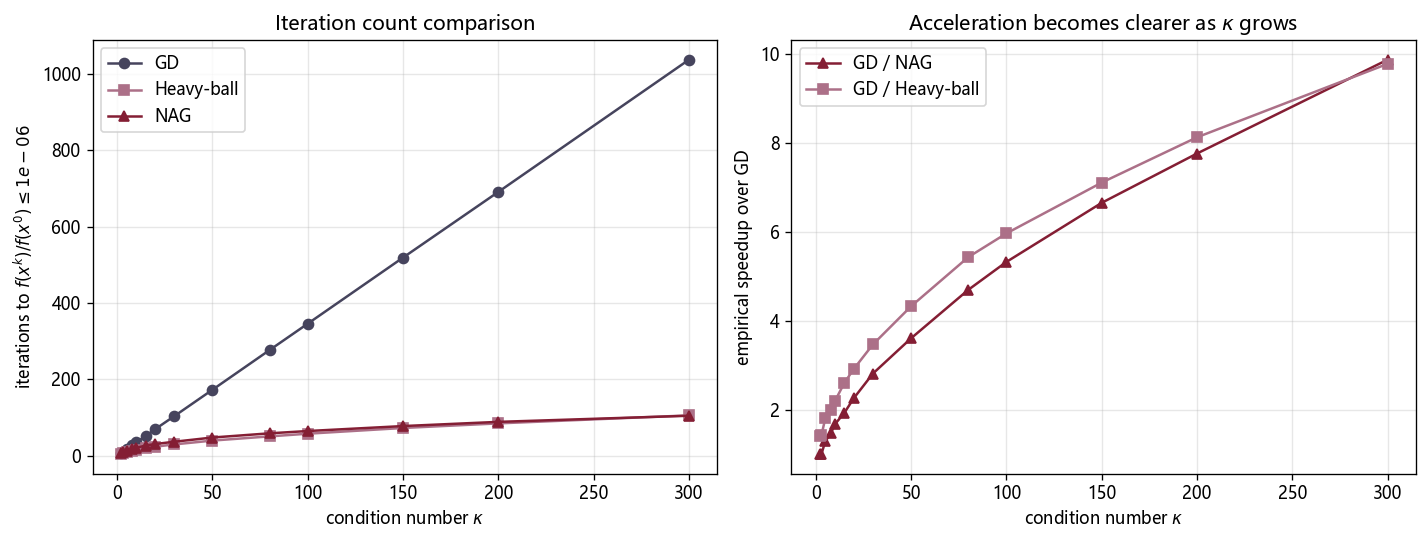

In [17]:
kappa_grid = np.array([2, 3, 5, 8, 10, 15, 20, 30, 50, 80, 100, 150, 200, 300])
tol = 1e-6
rows = []

for kappa in kappa_grid:
    gd_emp, gd_theory, gd_alpha, gd_rho = iterations_to_tol(kappa, x0=x0, tol=tol)
    hb_emp, hb_theory, hb_alpha, hb_beta, hb_rho = momentum_iterations_to_tol(kappa, x0=x0, tol=tol)
    nag_emp, nag_theory, nag_alpha, nag_beta, nag_rho = nag_iterations_to_tol(kappa, x0=x0, tol=tol)
    rows.append({
        "kappa": kappa,
        "GD_iters": gd_emp,
        "HB_iters": hb_emp,
        "NAG_iters": nag_emp,
        "GD_over_NAG": gd_emp / nag_emp,
        "GD_over_HB": gd_emp / hb_emp,
        "NAG_beta": nag_beta,
        "NAG_rho_rough": nag_rho,
    })

all_speed_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].plot(all_speed_df["kappa"], all_speed_df["GD_iters"], "o-", color=BLUE, label="GD")
axes[0].plot(all_speed_df["kappa"], all_speed_df["HB_iters"], "s-", color=ORANGE, label="Heavy-ball")
axes[0].plot(all_speed_df["kappa"], all_speed_df["NAG_iters"], "^-", color=SHANSHU, label="NAG")
axes[0].set_xlabel(r"condition number $\kappa$")
axes[0].set_ylabel(fr"iterations to $f(x^k)/f(x^0)\leq {tol:g}$")
axes[0].set_title("Iteration count comparison")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(all_speed_df["kappa"], all_speed_df["GD_over_NAG"], "^-", color=SHANSHU, label="GD / NAG")
axes[1].plot(all_speed_df["kappa"], all_speed_df["GD_over_HB"], "s-", color=ORANGE, label="GD / Heavy-ball")
axes[1].set_xlabel(r"condition number $\kappa$")
axes[1].set_ylabel("empirical speedup over GD")
axes[1].set_title("Acceleration becomes clearer as $\kappa$ grows")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
out = PICS / "chapter8_gd_hb_nag_iteration_speedup.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

all_speed_df

## NAG 实验结论

这组实验可以用于课件中的 Nesterov 部分：

1. 与 GD 相比，NAG 利用前瞻点计算梯度，明显减少病态二次函数上的迭代次数；
2. 条件数越大，普通 GD 的慢收敛越明显，NAG 的提升也越容易观察；
3. Heavy-ball 在这个二次函数例子上可能更快，但它的参数和稳定性更依赖问题结构；
4. NAG 的课程价值在于：它把“动量”和“前瞻梯度”结合起来，并在光滑凸优化中给出经典的加速复杂度。

## 补充实验 13：两个更复杂的目标函数

前面的实验都基于二维二次函数，它的好处是条件数、最优步长和理论收敛因子都非常清楚。为了更接近实际优化问题，下面再加入两个稍微复杂的例子：

1. **Rosenbrock 函数**：经典非凸测试函数，具有狭长弯曲谷底，适合观察轨迹；
2. **带 $L_2$ 正则的逻辑回归目标**：来自机器学习经验风险最小化，适合观察损失下降。

这两个例子里，参数不再是理论最优参数，而是为了课堂演示选择的稳定参数。重点是比较三种算法的实际表现，而不是证明最优复杂度。

In [18]:
def run_first_order_method(f, grad, x0, method="gd", alpha=1e-3, beta=0.9, max_iter=1000, tol=1e-10):
    """Run GD, Heavy-ball, or NAG for a general differentiable objective."""
    x = np.array(x0, dtype=float)
    x_prev = x.copy()
    v = np.zeros_like(x)
    xs = [x.copy()]
    fs = [float(f(x))]
    grad_norms = [float(np.linalg.norm(grad(x)))]

    for _ in range(max_iter):
        if method == "gd":
            g = grad(x)
            x_next = x - alpha * g
        elif method == "heavy_ball":
            g = grad(x)
            v = beta * v - alpha * g
            x_next = x + v
        elif method == "nag":
            y = x + beta * (x - x_prev)
            g = grad(y)
            x_next = y - alpha * g
        else:
            raise ValueError(f"unknown method: {method}")

        x_prev, x = x, x_next
        fx = float(f(x))
        xs.append(x.copy())
        fs.append(fx)
        grad_norms.append(float(np.linalg.norm(grad(x))))

        if grad_norms[-1] <= tol:
            break
        if (not np.all(np.isfinite(x))) or (not np.isfinite(fx)) or np.linalg.norm(x) > 1e10:
            break

    return np.array(xs), np.array(fs), np.array(grad_norms)


def relative_gap(values, f_star=None, eps=1e-16):
    """Convert function values to a nonnegative relative gap curve."""
    values = np.asarray(values, dtype=float)
    if f_star is None:
        f_star = np.nanmin(values)
    gaps = np.maximum(values - f_star, eps)
    return gaps / max(gaps[0], eps)

## 例子 A：Rosenbrock 函数

Rosenbrock 函数定义为

$$
f(x_1,x_2)=100(x_2-x_1^2)^2+(1-x_1)^2.
$$

它的全局最优点是 $(1,1)$，最优值为 $0$。这个函数的困难不在于维度高，而在于谷底又窄又弯：算法需要先进入谷底，再沿着弯曲方向慢慢移动到最优点。

这个例子适合展示：

- GD 容易沿谷底缓慢移动；
- Heavy-ball 和 NAG 可能更快，但也更容易因为动量带来震荡；
- 非凸函数上不能简单套用前面强凸二次函数的理论参数。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_rosenbrock_gd_hb_nag.png


,method,iterations,final_f,final_grad_norm,alpha,beta
0,GD,20000,1.938492e-08,1.244451e-04,0.001,0.0
1,Heavy-ball,8615,1.247056e-16,9.980234e-09,0.001,0.8
2,NAG,8639,1.251873e-16,9.999488e-09,0.001,0.8


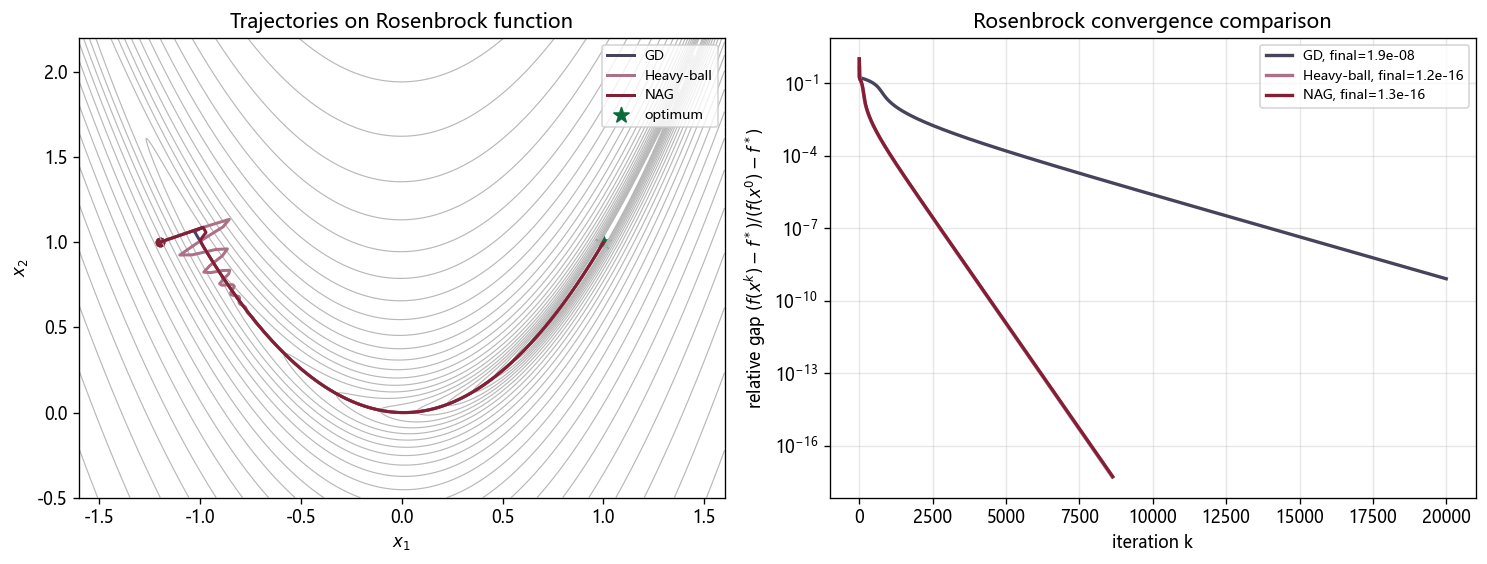

In [19]:
def rosenbrock_f(x):
    x1, x2 = x
    return 100.0 * (x2 - x1**2) ** 2 + (1.0 - x1) ** 2


def rosenbrock_grad(x):
    x1, x2 = x
    return np.array([
        -400.0 * x1 * (x2 - x1**2) - 2.0 * (1.0 - x1),
        200.0 * (x2 - x1**2),
    ])


x0_rosen = np.array([-1.2, 1.0])
rosen_configs = {
    "GD": {"method": "gd", "alpha": 1e-3, "beta": 0.0, "color": BLUE},
    "Heavy-ball": {"method": "heavy_ball", "alpha": 1e-3, "beta": 0.80, "color": ORANGE},
    "NAG": {"method": "nag", "alpha": 1e-3, "beta": 0.80, "color": SHANSHU},
}

rosen_results = {}
for name, cfg in rosen_configs.items():
    xs, fs, gs = run_first_order_method(
        rosenbrock_f,
        rosenbrock_grad,
        x0_rosen,
        method=cfg["method"],
        alpha=cfg["alpha"],
        beta=cfg["beta"],
        max_iter=20000,
        tol=1e-8,
    )
    rosen_results[name] = {"xs": xs, "fs": fs, "gs": gs, **cfg}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))

# Contour and trajectories
x_grid = np.linspace(-1.6, 1.6, 500)
y_grid = np.linspace(-0.5, 2.2, 500)
X, Y = np.meshgrid(x_grid, y_grid)
Z = 100.0 * (Y - X**2) ** 2 + (1.0 - X) ** 2
levels = np.logspace(-1, 3.2, 28)
axes[0].contour(X, Y, Z, levels=levels, colors="0.72", linewidths=0.7)
for name, res in rosen_results.items():
    xs = res["xs"]
    axes[0].plot(xs[:, 0], xs[:, 1], color=res["color"], linewidth=1.8, label=name)
    axes[0].scatter(xs[0, 0], xs[0, 1], color=res["color"], marker="o", s=24)
axes[0].scatter([1], [1], color=DEEP_GREEN, marker="*", s=90, label="optimum")
axes[0].set_xlim(-1.6, 1.6)
axes[0].set_ylim(-0.5, 2.2)
axes[0].set_xlabel(r"$x_1$")
axes[0].set_ylabel(r"$x_2$")
axes[0].set_title("Trajectories on Rosenbrock function")
axes[0].legend(fontsize=8)

# Function value curves
for name, res in rosen_results.items():
    rel = relative_gap(res["fs"], f_star=0.0)
    axes[1].semilogy(rel, color=res["color"], linewidth=2, label=f"{name}, final={res['fs'][-1]:.1e}")
axes[1].set_xlabel("iteration k")
axes[1].set_ylabel(r"relative gap $(f(x^k)-f^*)/(f(x^0)-f^*)$")
axes[1].set_title("Rosenbrock convergence comparison")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8)

fig.tight_layout()
out = PICS / "chapter8_rosenbrock_gd_hb_nag.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

pd.DataFrame([
    {
        "method": name,
        "iterations": len(res["fs"]) - 1,
        "final_f": res["fs"][-1],
        "final_grad_norm": res["gs"][-1],
        "alpha": res["alpha"],
        "beta": res["beta"],
    }
    for name, res in rosen_results.items()
])

## 例子 B：带 $L_2$ 正则的逻辑回归

第二个例子来自机器学习中的经验风险最小化。给定样本 $(a_i,b_i)$，其中 $b_i\in\{-1,1\}$，考虑

$$
F(w)=\frac1n\sum_{i=1}^n \log\left(1+\exp(-b_i a_i^\top w)\right)+\frac\lambda2\|w\|^2.
$$

这是一个光滑凸目标；加入 $L_2$ 正则后还是强凸的。这个例子比二维二次函数更接近真实训练问题，但仍然足够简单，适合课堂演示三种一阶方法的差异。

下面构造一个特征尺度差异较大的合成数据集，让问题具有一定病态性。

In [20]:
def make_logistic_data(n=600, d=20, seed=7):
    """Synthetic logistic-regression data with anisotropic feature scales."""
    rng = np.random.default_rng(seed)
    scales = np.geomspace(1.0, 25.0, d)
    A = rng.normal(size=(n, d)) * scales
    w_true = rng.normal(size=d) / scales
    logits = A @ w_true
    probs = 1.0 / (1.0 + np.exp(-logits))
    y = np.where(rng.uniform(size=n) < probs, 1.0, -1.0)
    return A, y, w_true


def logistic_loss_factory(A, y, lam=1e-2):
    n = A.shape[0]

    def f(w):
        z = y * (A @ w)
        return float(np.mean(np.logaddexp(0.0, -z)) + 0.5 * lam * np.dot(w, w))

    def grad(w):
        z = y * (A @ w)
        coeff = -y / (1.0 + np.exp(z))
        return (A.T @ coeff) / n + lam * w

    return f, grad


A, y, w_true = make_logistic_data(n=600, d=20, seed=7)
lam = 1e-2
log_f, log_grad = logistic_loss_factory(A, y, lam=lam)

# A safe global Lipschitz bound for logistic loss gradient:
# L <= ||A||_2^2/(4n) + lambda.
sigma_max = np.linalg.norm(A, ord=2)
L_bound = sigma_max**2 / (4 * A.shape[0]) + lam
mu_bound = lam
kappa_bound = L_bound / mu_bound
alpha_gd_log = 1.0 / L_bound
beta_nag_log = (np.sqrt(L_bound) - np.sqrt(mu_bound)) / (np.sqrt(L_bound) + np.sqrt(mu_bound))

print(f"L_bound={L_bound:.3f}, mu={mu_bound:.3f}, kappa_bound≈{kappa_bound:.1f}")
print(f"GD/NAG alpha={alpha_gd_log:.4e}, NAG beta={beta_nag_log:.3f}")

L_bound=151.235, mu=0.010, kappa_bound≈15123.5
GD/NAG alpha=6.6122e-03, NAG beta=0.984


saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_logistic_gd_hb_nag.png


,method,iterations,final_loss,final_grad_norm,alpha,beta
0,GD,1200,0.269391,0.072402,0.006612,0.000000
1,Heavy-ball,1200,0.237934,0.008968,0.004959,0.850000
2,NAG,1200,0.237087,0.000005,0.006612,0.983868


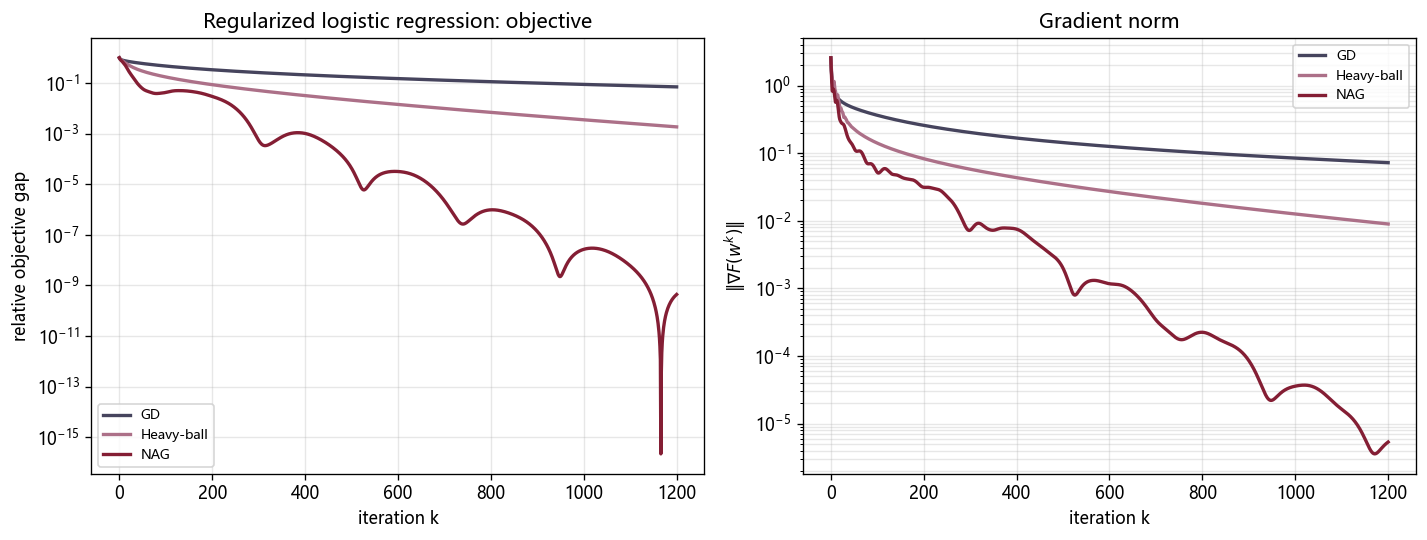

In [21]:
w0 = np.zeros(A.shape[1])
max_iter_log = 1200

log_configs = {
    "GD": {"method": "gd", "alpha": alpha_gd_log, "beta": 0.0, "color": BLUE},
    "Heavy-ball": {"method": "heavy_ball", "alpha": 0.75 * alpha_gd_log, "beta": 0.85, "color": ORANGE},
    "NAG": {"method": "nag", "alpha": alpha_gd_log, "beta": beta_nag_log, "color": SHANSHU},
}

log_results = {}
for name, cfg in log_configs.items():
    xs, fs, gs = run_first_order_method(
        log_f,
        log_grad,
        w0,
        method=cfg["method"],
        alpha=cfg["alpha"],
        beta=cfg["beta"],
        max_iter=max_iter_log,
        tol=1e-8,
    )
    log_results[name] = {"xs": xs, "fs": fs, "gs": gs, **cfg}

f_best = min(np.min(res["fs"]) for res in log_results.values())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for name, res in log_results.items():
    rel = relative_gap(res["fs"], f_star=f_best)
    axes[0].semilogy(rel, color=res["color"], linewidth=2, label=name)
    axes[1].semilogy(res["gs"], color=res["color"], linewidth=2, label=name)

axes[0].set_xlabel("iteration k")
axes[0].set_ylabel("relative objective gap")
axes[0].set_title("Regularized logistic regression: objective")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_xlabel("iteration k")
axes[1].set_ylabel(r"$\|\nabla F(w^k)\|$")
axes[1].set_title("Gradient norm")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8)

fig.tight_layout()
out = PICS / "chapter8_logistic_gd_hb_nag.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

pd.DataFrame([
    {
        "method": name,
        "iterations": len(res["fs"]) - 1,
        "final_loss": res["fs"][-1],
        "final_grad_norm": res["gs"][-1],
        "alpha": res["alpha"],
        "beta": res["beta"],
    }
    for name, res in log_results.items()
])

## 两个复杂例子的课堂解读

这两个例子可以放在课件或课堂演示的最后，用来提醒学生：

1. **二次函数实验**最适合解释理论，因为条件数和收敛因子都能精确计算；
2. **Rosenbrock 函数**说明非凸、弯曲谷底会让轨迹更复杂，动量可能加速，也可能带来震荡；
3. **逻辑回归目标**说明在真实机器学习损失上，加速方法通常能更快降低目标值和梯度范数；
4. 实际问题中，动量参数和步长需要调参，不能机械套用二次函数上的最优参数。

## 应用案例一：线性方程组 $Ax=b$ 与二次优化的一致性

很多工程计算问题最终会变成大型线性方程组，例如有限元结构分析、热传导方程离散化、电路网络求解等。如果 $A\succ0$，那么求解

$$
Ax=b
$$

等价于求解二次优化问题

$$
\min_x f(x)=\frac12 x^\top A x-b^\top x.
$$

因为

$$
\nabla f(x)=Ax-b,
$$

所以 $\nabla f(x)=0$ 与 $Ax=b$ 完全等价。

这个实验分两步：

1. 直接用线性代数方法求解 $Ax=b$；
2. 用 GD、Heavy-ball、NAG 最小化二次函数，比较最终解是否与直接解一致。

In [22]:
def make_spd_system(n=80, kappa=200, seed=11):
    """Construct A=Q diag(eigs) Q^T with a prescribed condition number."""
    rng = np.random.default_rng(seed)
    M = rng.normal(size=(n, n))
    Q, _ = np.linalg.qr(M)
    eigs = np.geomspace(1.0, kappa, n)
    A = Q @ np.diag(eigs) @ Q.T
    x_true = rng.normal(size=n)
    b = A @ x_true
    return A, b, x_true, eigs


def run_quadratic_system_method(A, b, method="gd", alpha=None, beta=0.0, max_iter=3000, tol=1e-10):
    """Run GD, Heavy-ball, or NAG on 1/2 x^T A x - b^T x."""
    n = len(b)
    x = np.zeros(n)
    x_prev = x.copy()
    v = np.zeros(n)
    x_direct = np.linalg.solve(A, b)
    f_star = 0.5 * x_direct @ A @ x_direct - b @ x_direct
    b_norm = max(np.linalg.norm(b), 1e-16)

    xs = [x.copy()]
    fs = [0.5 * x @ A @ x - b @ x]
    residuals = [np.linalg.norm(A @ x - b) / b_norm]
    solution_errors = [np.linalg.norm(x - x_direct) / max(np.linalg.norm(x_direct), 1e-16)]

    for _ in range(max_iter):
        if method == "gd":
            g = A @ x - b
            x_next = x - alpha * g
        elif method == "heavy_ball":
            g = A @ x - b
            v = beta * v - alpha * g
            x_next = x + v
        elif method == "nag":
            y = x + beta * (x - x_prev)
            g = A @ y - b
            x_next = y - alpha * g
        else:
            raise ValueError(method)

        x_prev, x = x, x_next
        f_val = 0.5 * x @ A @ x - b @ x
        xs.append(x.copy())
        fs.append(f_val)
        residuals.append(np.linalg.norm(A @ x - b) / b_norm)
        solution_errors.append(np.linalg.norm(x - x_direct) / max(np.linalg.norm(x_direct), 1e-16))
        if residuals[-1] <= tol:
            break
        if (not np.all(np.isfinite(x))) or np.linalg.norm(x) > 1e12:
            break

    return {
        "xs": np.array(xs),
        "fs": np.array(fs),
        "f_star": f_star,
        "residuals": np.array(residuals),
        "solution_errors": np.array(solution_errors),
        "x_final": x.copy(),
        "x_direct": x_direct,
    }

direct solve error ||x_direct-x_true||/||x_true|| = 4.02e-15
saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_linear_system_quadratic_equivalence.png


,method,iterations,final_relative_residual,relative_error_to_direct,alpha,beta
0,GD,1323,9.950066e-09,3.063915e-07,0.009950,0.000000
1,Heavy-ball,133,8.628787e-09,2.073819e-08,0.017446,0.753282
2,NAG,213,9.550840e-09,4.359317e-07,0.005000,0.867918


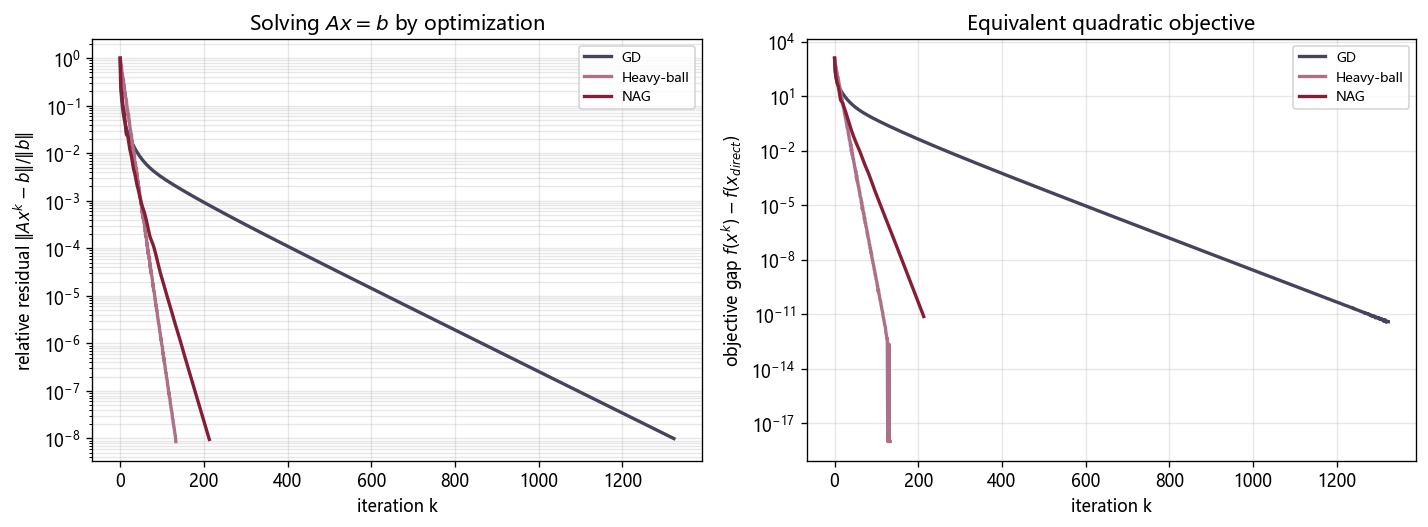

In [23]:
n = 80
kappa_system = 200
A_sys, b_sys, x_true_sys, eigs_sys = make_spd_system(n=n, kappa=kappa_system, seed=11)
mu_sys, L_sys = eigs_sys.min(), eigs_sys.max()

x_direct = np.linalg.solve(A_sys, b_sys)
print(f"direct solve error ||x_direct-x_true||/||x_true|| = {np.linalg.norm(x_direct-x_true_sys)/np.linalg.norm(x_true_sys):.2e}")

alpha_gd_sys = 2.0 / (L_sys + mu_sys)
alpha_hb_sys = 4.0 / (np.sqrt(L_sys) + np.sqrt(mu_sys)) ** 2
beta_hb_sys = ((np.sqrt(L_sys) - np.sqrt(mu_sys)) / (np.sqrt(L_sys) + np.sqrt(mu_sys))) ** 2
alpha_nag_sys = 1.0 / L_sys
beta_nag_sys = (np.sqrt(L_sys) - np.sqrt(mu_sys)) / (np.sqrt(L_sys) + np.sqrt(mu_sys))

system_configs = {
    "GD": {"method": "gd", "alpha": alpha_gd_sys, "beta": 0.0, "color": BLUE},
    "Heavy-ball": {"method": "heavy_ball", "alpha": alpha_hb_sys, "beta": beta_hb_sys, "color": ORANGE},
    "NAG": {"method": "nag", "alpha": alpha_nag_sys, "beta": beta_nag_sys, "color": SHANSHU},
}

system_results = {}
for name, cfg in system_configs.items():
    res = run_quadratic_system_method(
        A_sys,
        b_sys,
        method=cfg["method"],
        alpha=cfg["alpha"],
        beta=cfg["beta"],
        max_iter=2500,
        tol=1e-8,
    )
    system_results[name] = {**res, **cfg}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for name, res in system_results.items():
    axes[0].semilogy(res["residuals"], color=res["color"], linewidth=2, label=name)
    axes[1].semilogy(np.maximum(res["fs"] - res["f_star"], 1e-18), color=res["color"], linewidth=2, label=name)

axes[0].set_xlabel("iteration k")
axes[0].set_ylabel(r"relative residual $\|Ax^k-b\|/\|b\|$")
axes[0].set_title(r"Solving $Ax=b$ by optimization")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].set_xlabel("iteration k")
axes[1].set_ylabel(r"objective gap $f(x^k)-f(x_{direct})$")
axes[1].set_title("Equivalent quadratic objective")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend(fontsize=8)

fig.tight_layout()
out = PICS / "chapter8_linear_system_quadratic_equivalence.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

pd.DataFrame([
    {
        "method": name,
        "iterations": len(res["residuals"]) - 1,
        "final_relative_residual": res["residuals"][-1],
        "relative_error_to_direct": np.linalg.norm(res["x_final"] - res["x_direct"]) / np.linalg.norm(res["x_direct"]),
        "alpha": res["alpha"],
        "beta": res["beta"],
    }
    for name, res in system_results.items()
])

### 步骤 1：生成原图与不同噪声图像

为了避免依赖外部图片，这里直接生成一张合成灰度图：包含圆形、矩形、斜线和不同灰度块。然后分别加入 $\sigma=0.05,0.15,0.30$ 的高斯噪声。

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_image_noise_levels.png


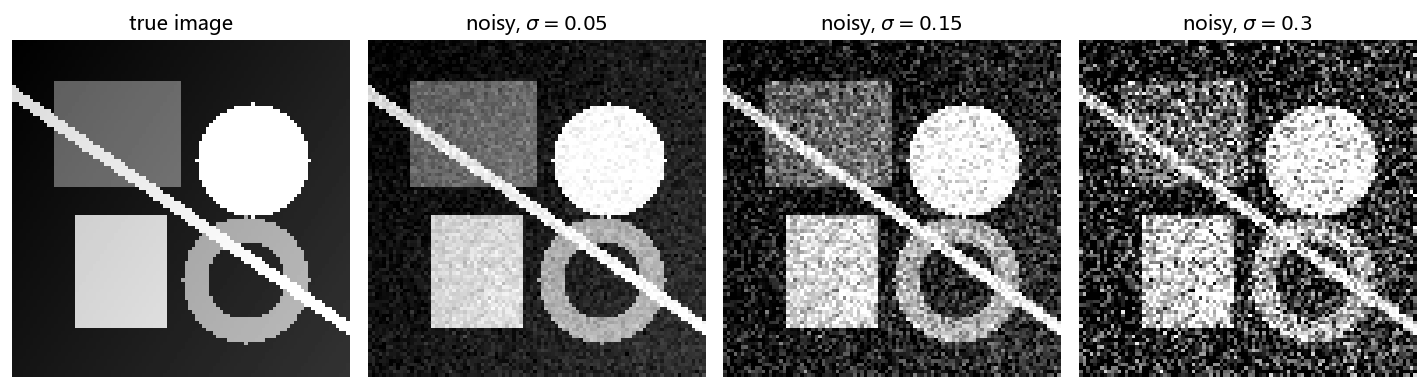

In [24]:
def make_synthetic_image(size=96):
    """Create a synthetic grayscale image with sharp edges and texture."""
    yy, xx = np.mgrid[0:size, 0:size]
    img = np.zeros((size, size), dtype=float)
    img[10:42, 10:50] = 0.35
    img[52:84, 14:45] = 0.75
    circle = (xx - 70) ** 2 + (yy - 32) ** 2 <= 16 ** 2
    img[circle] = 0.95
    ring = ((xx - 68) ** 2 + (yy - 70) ** 2 <= 18 ** 2) & ((xx - 68) ** 2 + (yy - 70) ** 2 >= 11 ** 2)
    img[ring] = 0.55
    diagonal = np.abs(yy - 0.72 * xx - 12) <= 2
    img[diagonal] = 0.90
    checker = ((xx // 6 + yy // 6) % 2 == 0) & (xx > 54) & (yy > 48)
    img[checker] = np.maximum(img[checker], 0.22)
    img += 0.08 * (xx / size) + 0.06 * (yy / size)
    return np.clip(img, 0.0, 1.0)


def gaussian_kernel1d(sigma=1.6, radius=5):
    grid = np.arange(-radius, radius + 1)
    kernel = np.exp(-(grid ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()


def gaussian_blur_periodic(img, sigma=1.6, radius=5):
    """Separable Gaussian blur with periodic boundary conditions."""
    kernel = gaussian_kernel1d(sigma=sigma, radius=radius)
    blurred = np.zeros_like(img, dtype=float)
    for offset, weight in zip(range(-radius, radius + 1), kernel):
        blurred += weight * np.roll(img, offset, axis=0)
    blurred2 = np.zeros_like(img, dtype=float)
    for offset, weight in zip(range(-radius, radius + 1), kernel):
        blurred2 += weight * np.roll(blurred, offset, axis=1)
    return blurred2


def add_gaussian_noise(img, sigma=0.15, seed=0):
    rng = np.random.default_rng(seed)
    noisy = img + sigma * rng.normal(size=img.shape)
    return np.clip(noisy, 0.0, 1.0)


img_true = make_synthetic_image(size=96)
blur_sigma = 1.8
blur_radius = 6
img_blurred = gaussian_blur_periodic(img_true, sigma=blur_sigma, radius=blur_radius)
noise_levels = [0.03, 0.08, 0.15]
degraded_images = {sigma: add_gaussian_noise(img_blurred, sigma=sigma, seed=42) for sigma in noise_levels}

fig, axes = plt.subplots(1, 5, figsize=(14, 3.2))
show_items = [("true image", img_true), (fr"blurred, $s={blur_sigma}$", img_blurred)] + [
    (fr"blurred + noise, $\sigma={sigma}$", degraded_images[sigma]) for sigma in noise_levels
]
for ax, (title, img) in zip(axes, show_items):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
out = PICS / "chapter8_image_degradation_levels.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

### 步骤 2：用优化算法恢复图像

对固定退化图像，例如模糊后加入 $\sigma=0.15$ 的噪声，求解

$$
\min_x f(x)=\frac12\|Kx-y\|^2+\frac\lambda2\left(\|D_xx\|^2+\|D_yx\|^2\right).
$$

这里 $D_x,D_y$ 是水平和垂直方向的离散差分算子，正则项惩罚相邻像素差。目标函数关于 $x$ 的梯度是

$$
\nabla f(x)=K^\top(Kx-y)+\lambda(D_x^\top D_x+D_y^\top D_y)x.
$$

若 $K$ 取对称高斯模糊，则 $K^\top=K$；$D_x^\top D_x+D_y^\top D_y$ 就是二维离散 Laplacian。下面使用周期边界实现，方便代码简洁。

In [27]:
def laplacian_periodic(x):
    """2D positive semidefinite graph Laplacian with periodic boundary."""
    return 4 * x - np.roll(x, 1, axis=0) - np.roll(x, -1, axis=0) - np.roll(x, 1, axis=1) - np.roll(x, -1, axis=1)


def image_restore_objective(x, y, lam, blur_sigma=1.8, blur_radius=6):
    blurred_x = gaussian_blur_periodic(x, sigma=blur_sigma, radius=blur_radius)
    data_diff = blurred_x - y
    grad_x = x - np.roll(x, 1, axis=1)
    grad_y = x - np.roll(x, 1, axis=0)
    return 0.5 * np.sum(data_diff**2) + 0.5 * lam * (np.sum(grad_x**2) + np.sum(grad_y**2))


def image_restore_grad(x, y, lam, blur_sigma=1.8, blur_radius=6):
    blurred_x = gaussian_blur_periodic(x, sigma=blur_sigma, radius=blur_radius)
    data_grad = gaussian_blur_periodic(blurred_x - y, sigma=blur_sigma, radius=blur_radius)
    return data_grad + lam * laplacian_periodic(x)


def run_image_restoration(
    y,
    lam=0.035,
    method="gd",
    alpha=None,
    beta=0.0,
    max_iter=350,
    tol=1e-8,
    blur_sigma=1.8,
    blur_radius=6,
):
    """Run GD, Heavy-ball, or NAG on the smooth deblurring objective."""
    if alpha is None:
        # The blur has norm <= 1 and the Laplacian has norm <= 8.
        alpha = 1.0 / (1.0 + 8.0 * lam)
    x = y.copy()
    x_prev = x.copy()
    v = np.zeros_like(x)
    fs = [image_restore_objective(x, y, lam, blur_sigma, blur_radius)]

    for _ in range(max_iter):
        if method == "gd":
            g = image_restore_grad(x, y, lam, blur_sigma, blur_radius)
            x_next = x - alpha * g
        elif method == "heavy_ball":
            g = image_restore_grad(x, y, lam, blur_sigma, blur_radius)
            v = beta * v - alpha * g
            x_next = x + v
        elif method == "nag":
            z = x + beta * (x - x_prev)
            g = image_restore_grad(z, y, lam, blur_sigma, blur_radius)
            x_next = z - alpha * g
        else:
            raise ValueError(method)
        x_prev, x = x, np.clip(x_next, 0.0, 1.0)
        fs.append(image_restore_objective(x, y, lam, blur_sigma, blur_radius))
        if np.linalg.norm(image_restore_grad(x, y, lam, blur_sigma, blur_radius)) / np.sqrt(x.size) <= tol:
            break
    return x, np.array(fs)


def mse(x, ref):
    return float(np.mean((x - ref) ** 2))


def psnr(x, ref, max_value=1.0):
    err = max(mse(x, ref), 1e-16)
    return 10.0 * np.log10(max_value**2 / err)

saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_image_denoising_restoration.png
saved to c:\Users\zhenw\Nutstore\1\个人信息表\论文阅读计划\latex\slides\优化理论与算法第八章\pics\chapter8_image_denoising_convergence.png


,image,MSE,PSNR,iterations,final_objective
0,noisy,0.053743,12.696809,0,254.029495
1,GD,0.024233,16.156013,32,122.794571
2,Heavy-ball,0.024233,16.156013,117,122.794571
3,NAG,0.024233,16.156013,37,122.794571


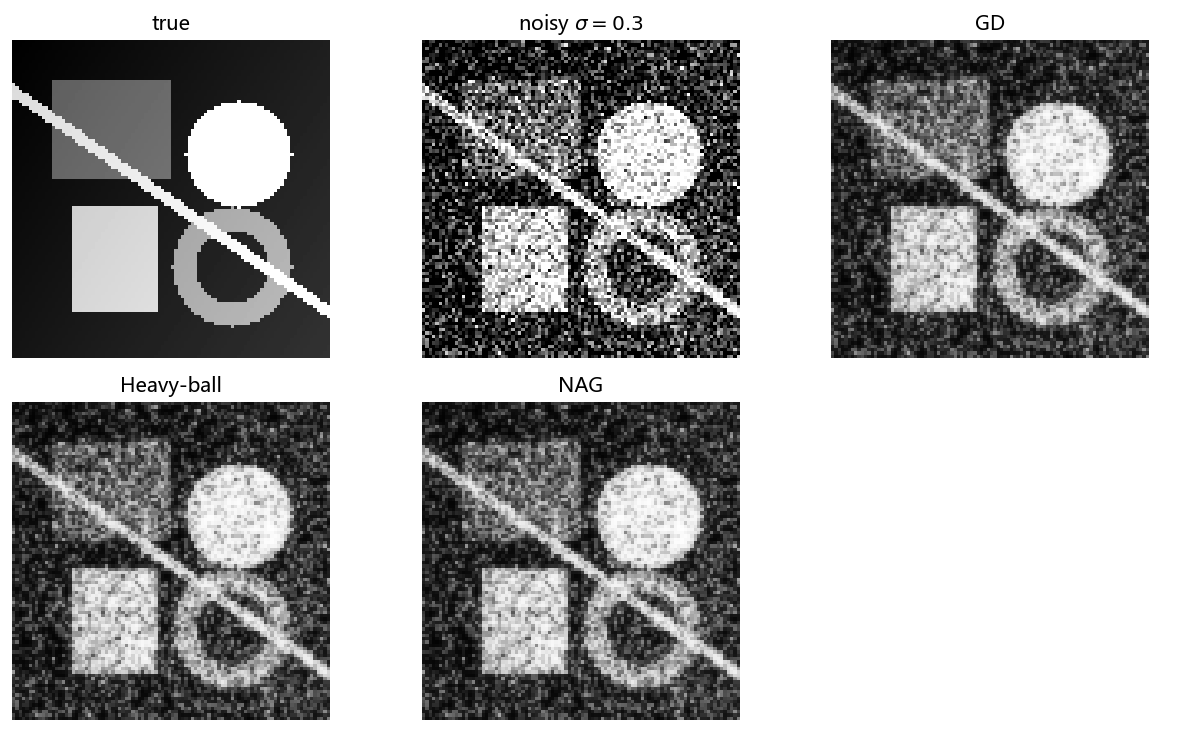

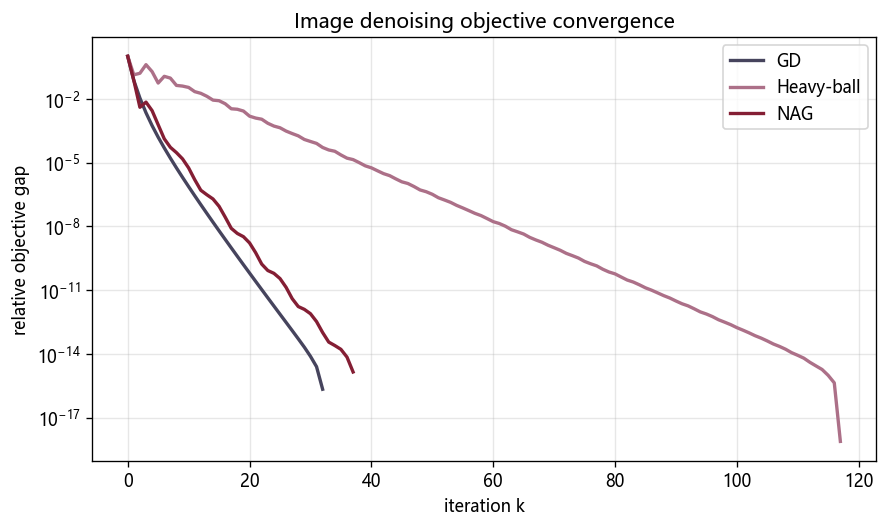

In [28]:
sigma_restore = 0.15
y_degraded = degraded_images[sigma_restore]
lam_img = 0.035
alpha_img = 0.92 / (1.0 + 8.0 * lam_img)

image_configs = {
    "GD": {"method": "gd", "alpha": alpha_img, "beta": 0.0, "color": BLUE},
    "Heavy-ball": {"method": "heavy_ball", "alpha": 0.82 * alpha_img, "beta": 0.72, "color": ORANGE},
    "NAG": {"method": "nag", "alpha": alpha_img, "beta": 0.72, "color": SHANSHU},
}

image_results = {}
for name, cfg in image_configs.items():
    restored, fs = run_image_restoration(
        y_degraded,
        lam=lam_img,
        method=cfg["method"],
        alpha=cfg["alpha"],
        beta=cfg["beta"],
        max_iter=260,
        blur_sigma=blur_sigma,
        blur_radius=blur_radius,
    )
    image_results[name] = {"restored": restored, "fs": fs, **cfg}

fig, axes = plt.subplots(2, 3, figsize=(10.5, 6.2))
axes = axes.ravel()
show_items = [("true", img_true), (fr"blur + noise $\sigma={sigma_restore}$", y_degraded)] + [
    (name, res["restored"]) for name, res in image_results.items()
]
for ax, (title, img) in zip(axes, show_items):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")
axes[-1].axis("off")
fig.tight_layout()
out = PICS / "chapter8_image_deblurring_restoration.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
error_items = [("degraded error", np.abs(y_degraded - img_true))] + [
    (f"{name} error", np.abs(res["restored"] - img_true)) for name, res in image_results.items()
]
for ax, (title, err) in zip(axes, error_items):
    ax.imshow(err, cmap="magma", vmin=0, vmax=0.55)
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
out = PICS / "chapter8_image_deblurring_error_maps.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
for name, res in image_results.items():
    rel = relative_gap(res["fs"], f_star=min(np.min(r["fs"]) for r in image_results.values()))
    ax.semilogy(rel, color=res["color"], linewidth=2, label=name)
ax.set_xlabel("iteration k")
ax.set_ylabel("relative objective gap")
ax.set_title("Image deblurring objective convergence")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
out = PICS / "chapter8_image_deblurring_convergence.png"
fig.savefig(out, bbox_inches="tight")
print(f"saved to {out}")

pd.DataFrame([
    {
        "image": "blurred+noisy",
        "MSE": mse(y_degraded, img_true),
        "PSNR": psnr(y_degraded, img_true),
        "iterations": 0,
        "final_objective": image_restore_objective(y_degraded, y_degraded, lam_img, blur_sigma, blur_radius),
    }
] + [
    {
        "image": name,
        "MSE": mse(res["restored"], img_true),
        "PSNR": psnr(res["restored"], img_true),
        "iterations": len(res["fs"]) - 1,
        "final_objective": res["fs"][-1],
    }
    for name, res in image_results.items()
])